In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Mounted at /content/drive/


In [3]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [4]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'C++']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df.drop_duplicates(subset=['question_code'])

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17227 entries, 64 to 61813
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            17227 non-null  object 
 1   country                             17227 non-null  object 
 2   contest_url                         17227 non-null  object 
 3   num_of_contest                      17227 non-null  int64  
 4   is_weekly                           17227 non-null  bool   
 5   rank                                17227 non-null  int64  
 6   score                               17227 non-null  int64  
 7   question_number                     17227 non-null  int64  
 8   question_language                   17227 non-null  object 
 9   question_code                       17227 non-null  object 
 10  number_of_lines                     17227 non-null  int64  
 11  names_set                           17227 non

<Axes: >

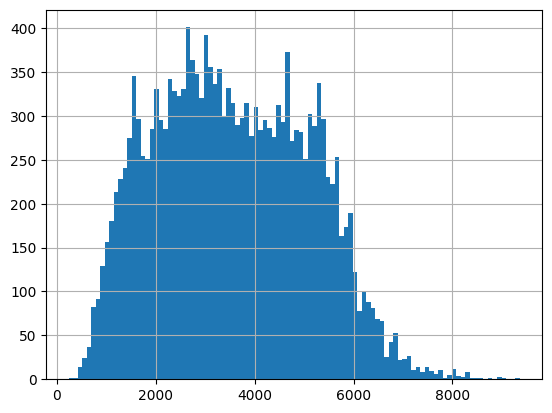

In [5]:
leetcode_questions_df.contest_finish_time_total_seconds.hist(bins=100)

In [6]:
# Define rank thresholds
percantage = 10

high_rank_threshold = leetcode_questions_df['contest_finish_time_total_seconds'].quantile(percantage/100)
low_rank_threshold = leetcode_questions_df['contest_finish_time_total_seconds'].quantile(1 - percantage/100)


leetcode_questions_df["experienced_programmer"] = leetcode_questions_df["contest_finish_time_total_seconds"] <= low_rank_threshold


high_rank_df = leetcode_questions_df[leetcode_questions_df["contest_finish_time_total_seconds"] < high_rank_threshold]
low_rank_df = leetcode_questions_df[leetcode_questions_df["contest_finish_time_total_seconds"] > low_rank_threshold]


filtered_df = pd.concat([high_rank_df, low_rank_df])

filtered_df.reset_index(drop=True, inplace=True)

filtered_df["experienced_programmer"].value_counts()

,count
experienced_programmer,
True,1720
False,1720


In [7]:
leetcode_questions_df = filtered_df

In [8]:
leetcode_questions_df.describe()

,num_of_contest,rank,score,question_number,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,...,function_density,loop_density,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated
count,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,...,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000
mean,285.179360,541.034593,16.051163,3.378779,54.972674,47.428198,23.945349,3.232267,3.758430,4.882849,...,0.049646,0.089641,0.108505,0.088174,3692.917151,2423.980814,1214.640407,0.041852,1585.792151,7.898547
std,124.726992,382.172368,2.953108,0.485153,52.781271,41.881027,22.815809,9.988877,4.331369,5.935727,...,0.040750,0.071999,0.075578,0.157392,2563.643015,1779.336745,1170.629504,0.087554,1881.008566,6.687682
min,117.000000,1.000000,8.000000,3.000000,6.000000,10.000000,4.000000,1.000000,0.000000,0.000000,...,0.007874,0.000000,0.000000,0.000000,237.000000,160.000000,0.000000,0.000001,108.000000,1.000000
25%,124.000000,140.000000,12.000000,3.000000,31.000000,30.000000,15.000000,1.000000,2.000000,2.000000,...,0.028571,0.039331,0.052632,0.000000,1207.000000,951.000000,365.000000,0.001832,840.000000,2.000000
50%,374.000000,578.000000,18.000000,3.000000,43.000000,36.000000,19.000000,1.000000,3.000000,4.000000,...,0.038462,0.080000,0.096154,0.000000,3568.000000,1440.000000,724.000000,0.008877,1204.000000,6.000000
75%,384.000000,867.000000,18.000000,4.000000,61.000000,47.250000,25.000000,2.000000,5.000000,6.000000,...,0.058824,0.120000,0.151515,0.128205,6031.000000,4396.500000,1878.250000,0.038555,1707.250000,11.000000
max,390.000000,1223.000000,20.000000,4.000000,793.000000,450.000000,291.000000,135.000000,69.000000,108.000000,...,0.589041,1.066667,0.538462,0.877551,9359.000000,5399.000000,5238.000000,0.951969,26867.000000,29.000000


In [9]:
X=leetcode_questions_df.drop('experienced_programmer',axis=1)
Y=leetcode_questions_df.experienced_programmer.astype(int)

In [10]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [11]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [14]:
X_test_text.to_csv('X_test_text.csv', index=False)

In [15]:
llm_df = pd.read_csv('/content/C___Code_Classification.csv')

In [16]:
y_test_llm = llm_df.classification.map({'experienced' : 1, 'unexperienced' : 0})

In [17]:
y_test

,experienced_programmer
2858,0
2831,0
381,1
1524,1
2498,0
...,...
1487,1
158,1
2234,0
1179,1


              precision    recall  f1-score   support

    low_rank       0.53      0.52      0.52       344
   high_rank       0.53      0.54      0.53       344

    accuracy                           0.53       688
   macro avg       0.53      0.53      0.53       688
weighted avg       0.53      0.53      0.53       688

f1_score_macro :  0.5290060851926978
f1_score_weighted :  0.5290060851926978


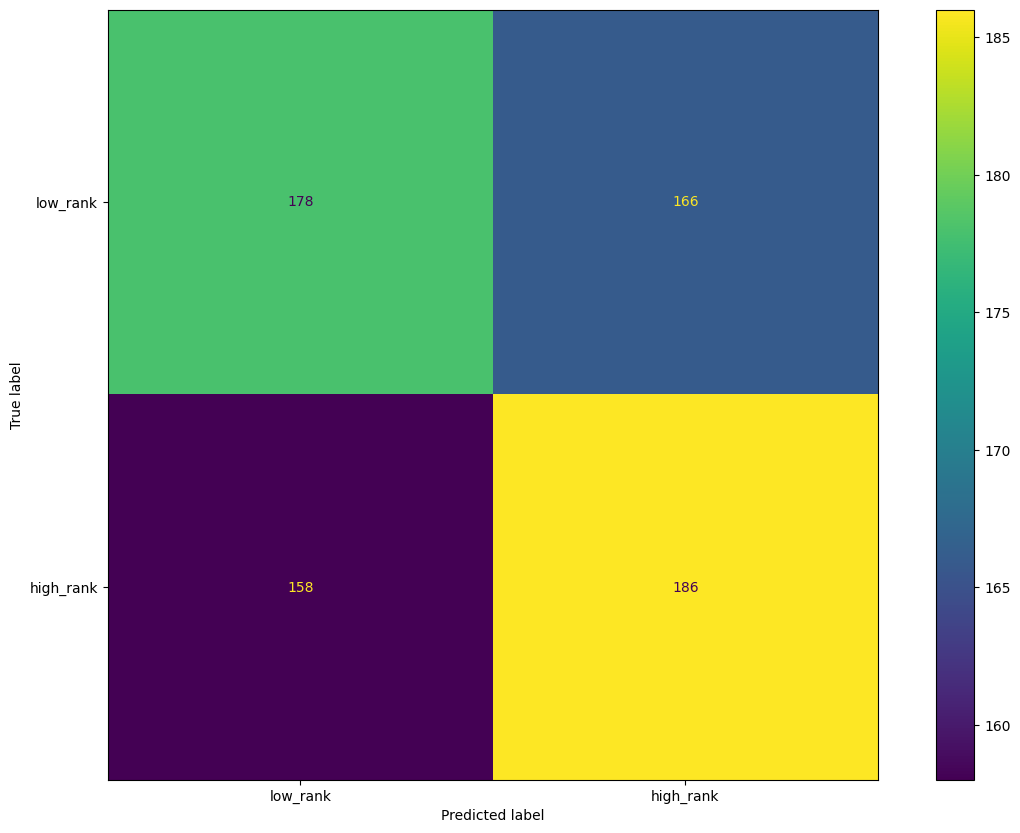

In [18]:
print(classification_report(y_test, y_test_llm, target_names=['low_rank','high_rank']))

print("f1_score_macro : ",f1_score(y_test, y_test_llm, average='macro'))
print("f1_score_weighted : ",f1_score(y_test, y_test_llm, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_llm), display_labels=['low_rank','high_rank'])

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()